In [13]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
bz_7_cluster_2_gene_id = 'orfm.bz_7.1_197'

In [3]:
genes_df = pd.read_csv('../data/genes.csv', index_col=0)
genes_df = genes_df[(genes_df.cluster_id == 2) | (genes_df.index == bz_7_cluster_2_gene_id)].copy()
# For some reason, the bz_7 cluster_2 protein did not get correctly clustered, though it is in the same position as the others (relative to the cluster_1
# ATPase), is the same length, and has a similar fold. Added it manually instead. It also does not seem to align with many other proteins in the cluster,
# except bz_8, oddly. 

FASTAFile.from_df(genes_df).write('../data/genes/cluster_2.faa')

In [15]:
MAX_ENTROPY = 0.1
msa = MSA(path='../data/genes/cluster_2.afa')
print('Number of columns in the MSA:', msa.n_cols)

def get_pairwise_identity(seqs):

    n = len(seqs)
    df = pd.DataFrame(np.zeros((n, n)), columns=seqs.index, index=seqs.index)
    for ((id_1, seq_1), (id_2, seq_2)) in itertools.combinations(seqs.to_dict().items(), 2):
        alignment = PairwiseAligner().align(seq_1, seq_2)[0]
        df.loc[id_1, id_2] = alignment.score / min(len(seq_1), len(seq_2))
        df.loc[id_2, id_1] = alignment.score / min(len(seq_1), len(seq_2))
    return df

# get_pairwise_identity(genes_df.seq)

Number of columns in the MSA: 215


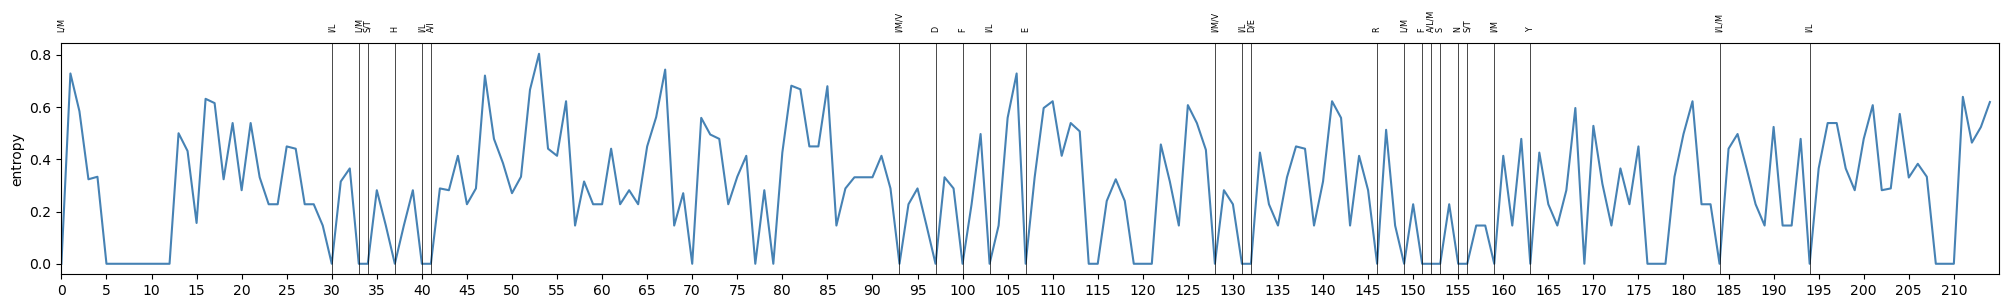

In [ ]:
def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_arr(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))

# x_min, x_max = 240, 270
x_min, x_max = 0, 215
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
ax.plot(np.arange(len(entropy)), entropy, color='steelblue')

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_arr().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_arr().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

ax.set_xticks(np.arange(x_min, x_max, 5))
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

# H, D, E, and C are potentially metal-binding. 

In [16]:
FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/cluster_2'
FOLDSEEK_TMP_DIR = '../data/tmp'
FOLDSEEK_QUERY_DATABASE_PATH = '../data/genes/foldseek/db/cluster_2/cluster_2'
FOLDSEEK_OUTPUT_DATABASE_PATH = '../data/genes/foldseek/db/cluster_2.out/cluster_2.out'
FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'
FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/cluster_2.tsv'

COLABFOLD_DIR = '../data/genes/colabfold'
COLABFOLD_FILE_NAME_PATTERN = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])

paths = {get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(COLABFOLD_FILE_NAME_PATTERN, path) is not None)}

# For the structural alignment, want to subset the structure to match the ATPase domain. 
for gene_id, path in paths.items():
    output_path = os.path.join(FOLDSEEK_INPUT_DIR, f'{gene_id}.pdb')
    subprocess.run(f'cp {path} {output_path}', shell=True, check=True)
    
print(f'foldseek createdb {FOLDSEEK_INPUT_DIR} {FOLDSEEK_QUERY_DATABASE_PATH}')
print(f'foldseek search {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_TMP_DIR} --alignment-type 1 -a')
print(f'foldseek convertalis {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_OUTPUT_PATH} --format-output {FOLDSEEK_FIELDS}')

foldseek_align_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, sep='\t', names=FOLDSEEK_FIELDS.replace('"', '').split(','))

# foldseek_align_df.pivot(index='query', columns='target', values='alntmscore')
# foldseek_align_df[foldseek_align_df['query'] == bz_7_cluster_2_gene_id ]

foldseek createdb ../data/genes/foldseek/structures/cluster_2 ../data/genes/foldseek/db/cluster_2/cluster_2
foldseek search ../data/genes/foldseek/db/cluster_2/cluster_2 ../data/genes/foldseek/db/cluster_2/cluster_2 ../data/genes/foldseek/db/cluster_2.out/cluster_2.out ../data/tmp --alignment-type 1 -a
foldseek convertalis ../data/genes/foldseek/db/cluster_2/cluster_2 ../data/genes/foldseek/db/cluster_2/cluster_2 ../data/genes/foldseek/db/cluster_2.out/cluster_2.out ../data/genes/foldseek/cluster_2.tsv --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"


In [6]:
FOLDSEEK_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
FOLDSEEK_TARGET_DATABASE_PATTERN = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index.values)].copy()
foldseek_search_df['num_gaps'] = [max(row.qaln.count('-'), row.taln.count('-')) for row in foldseek_search_df.itertuples()]
foldseek_search_df = foldseek_search_df.drop(columns=['cigar', 'qtmscore', 'ttmscore', 'qheader', 'rmsd', 'fident', 'pident', 'nident', 'taxid'], errors='ignore')

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

Number of Foldseek hits for orfm.bz_0.1_198: 2193 	pdb (595) alphafold_swissprot (559) alphafold_uniprot (546) bfvd (493)
Number of Foldseek hits for orfm.bz_1.1_170: 1371 	alphafold_uniprot (429) bfvd (381) pdb (310) alphafold_swissprot (251)
Number of Foldseek hits for orfm.bz_10.1_5: 128 	bfvd (57) pdb (45) alphafold_swissprot (18) alphafold_uniprot (8)
Number of Foldseek hits for orfm.bz_11.1_16: 1780 	alphafold_uniprot (661) bfvd (415) alphafold_swissprot (354) pdb (350)
Number of Foldseek hits for orfm.bz_2.1_13: 2111 	alphafold_uniprot (752) pdb (509) bfvd (448) alphafold_swissprot (402)
Number of Foldseek hits for orfm.bz_3.1_33: 2326 	pdb (639) alphafold_uniprot (620) alphafold_swissprot (569) bfvd (498)
Number of Foldseek hits for orfm.bz_4.1_191: 1999 	pdb (549) alphafold_uniprot (544) bfvd (495) alphafold_swissprot (411)
Number of Foldseek hits for orfm.bz_5.1_157: 1670 	alphafold_uniprot (705) pdb (380) bfvd (310) alphafold_swissprot (275)
Number of Foldseek hits for orfm.

In [7]:
filters = dict()
filters['large_e_value'] = foldseek_search_df.evalue > 0.5
# filters['too_many_gaps'] = (foldseek_search_df.gapopen > 15) | (foldseek_search_df.num_gaps > 50)
filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.6
filters['low_query_coverage'] = foldseek_search_df.qcov < 0.5
filters['low_target_coverage'] = foldseek_search_df.tcov < 0.5
# filters['short_target'] = (foldseek_search_df.tlen < 50) | (foldseek_search_df.num_gaps > 50)

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of filtered Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

apply_filters: 6 entries removed by large_e_value.
apply_filters: 14903 entries removed by low_tm_score.
apply_filters: 1541 entries removed by low_query_coverage.
apply_filters: 5870 entries removed by low_target_coverage.
Number of filtered Foldseek hits for orfm.bz_0.1_198: 44 	bfvd (26) pdb (9) alphafold_swissprot (7) alphafold_uniprot (2)
Number of filtered Foldseek hits for orfm.bz_1.1_170: 83 	alphafold_uniprot (28) bfvd (25) pdb (18) alphafold_swissprot (12)
Number of filtered Foldseek hits for orfm.bz_10.1_5: 1 	bfvd (1)
Number of filtered Foldseek hits for orfm.bz_11.1_16: 16 	bfvd (11) alphafold_swissprot (4) pdb (1)
Number of filtered Foldseek hits for orfm.bz_2.1_13: 57 	bfvd (24) pdb (20) alphafold_swissprot (10) alphafold_uniprot (3)
Number of filtered Foldseek hits for orfm.bz_3.1_33: 42 	bfvd (28) pdb (7) alphafold_swissprot (4) alphafold_uniprot (3)
Number of filtered Foldseek hits for orfm.bz_4.1_191: 13 	bfvd (6) pdb (5) alphafold_swissprot (2)
Number of filtered Fo

In [8]:
print(foldseek_search_df.sort_values('alntmscore', ascending=False)[['theader', 'alntmscore', 'qcov', 'tcov']].theader.tolist())
# 8yy1-assembly1_Z Vo domain of V/A-ATPase from Thermus thermophilus state3
# ATPase protein 9
# Q6MLJ0
# DUF4105 Domain found in putative membrane proteins in bacteria and archaea.
# Transmembrane protein 196 is human.
# T4 recombination mediator protein UvsY is not transmembrane.
# 5jsn-assembly2_D Bcl2-inhibitor complex is human.

foldseek_search_df.sort_values('alntmscore', ascending=False)[['theader', 'alntmscore', 'qcov', 'tcov']].iloc[:30]

['AF-A0A928H2R6-F1-model_v6 DUF4105 domain-containing protein', '4zws-assembly1_E Crystal Structure of the Bacteriophage T4 recombination mediator protein UvsY, Lattice Type III', 'E2CU06', '5jsn-assembly2_D Bcl2-inhibitor complex', 'AF-Q5HYL7-4-F1-model_v6 Transmembrane protein 196', 'D9I5Z1', 'AF-D3YWQ9-F1-model_v6 Transmembrane protein 196', 'A0A482MH23', 'AF-O74872-F1-model_v6 Meiotically up-regulated gene 111 protein', 'AF-B1AIC5-F1-model_v6 ATP synthase subunit c', '8rz0-assembly1_A Synthetic immunogen RH5-34EM bound to monoclonal antibody R5.016', 'A0A345MVX9', 'A0A6M6DFK3', 'AF-Q9ES43-F1-model_v6 Choline/ethanolamine transporter FLVCR1', 'A0A1W6DXQ8', '5sv0-assembly2_J Structure of the ExbB/ExbD complex from E. coli at pH 7.0', 'AF-Q10097-F1-model_v6 Uncharacterized transporter C11D3.18C', 'A0A5P8D383', 'AF-Q5F3N0-F1-model_v6 Sugar phosphate exchanger 3', '2p5t-assembly2_E Molecular and structural characterization of the PezAT chromosomal toxin-antitoxin system of the human pat

,theader,alntmscore,qcov,tcov
59532,AF-A0A928H2R6-F1-model_v6 DUF4105 domain-conta...,0.7899,0.514,0.755
107153,4zws-assembly1_E Crystal Structure of the Bact...,0.7842,0.754,0.562
70701,E2CU06,0.7552,0.569,0.699
100797,5jsn-assembly2_D Bcl2-inhibitor complex,0.7527,0.796,0.539
125558,AF-Q5HYL7-4-F1-model_v6 Transmembrane protein 196,0.7451,0.959,0.547
70700,D9I5Z1,0.7431,0.908,0.593
125560,AF-D3YWQ9-F1-model_v6 Transmembrane protein 196,0.7421,0.959,0.534
115817,A0A482MH23,0.7383,0.911,0.667
117553,AF-O74872-F1-model_v6 Meiotically up-regulated...,0.7371,0.827,0.880
75609,AF-B1AIC5-F1-model_v6 ATP synthase subunit c,0.7302,0.782,0.569


In [9]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'
COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
COLABFOLD_PLDDTS = dict()

for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):    
    if get_gene_id(path) not in genes_df.index.values: 
        continue 

    with open(path, 'r') as f:
        scores = json.load(f)
        plddts = np.array(scores['plddt'])
        COLABFOLD_PLDDTS[get_gene_id(path)] = plddts

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}
# fig, ax = plt.subplots(figsize=(10, 3.5))
# for gene_id, plddts in COLABFOLD_PLDDTS.items():
#     ax.plot(np.arange(len(plddts)), plddts, label=gene_id, color=palette[gene_id])
# ax.set_xlim(xmin=0, xmax=180)
# ax.set_ylabel('pLDDT')
# ax.set_xlabel('position')
# plt.show()

pattern = '(' + '|'.join(genes_df.index) + ')' + r'_relaxed_rank_001_alphafold2_ptm_model_\d_seed_\d\d\d\.pdb'
paths = [path for path in glob.glob(os.path.join(COLABFOLD_DIR, '**', '*')) if (re.search(pattern, path) is not None)]
for path in paths:
    output_path = os.path.join('/home/prichter/Documents/banfield/betazoid/data/genes/metal3d/', f'{get_gene_id(path)}')
    cmd = f'metal3d --pdb {os.path.abspath(path)} --metalbinding --writeprobes --probefile {output_path}.pdb --maxp --writecube --cubefile {output_path}.cube --softext'
    print(cmd)

metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_0/orfm.bz_0.1_198_relaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb --metalbinding --writeprobes --probefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_0.1_198.pdb --maxp --writecube --cubefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_0.1_198.cube --softext
metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_5/orfm.bz_5.1_157_relaxed_rank_001_alphafold2_ptm_model_4_seed_000.pdb --metalbinding --writeprobes --probefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_5.1_157.pdb --maxp --writecube --cubefile /home/prichter/Documents/banfield/betazoid/data/genes/metal3d/orfm.bz_5.1_157.cube --softext
metal3d --pdb /home/prichter/Documents/banfield/betazoid/data/genes/colabfold/bz_1/orfm.bz_1.1_170_relaxed_rank_001_alphafold2_ptm_model_3_seed_000.pdb --metalbinding --writeprobes --probefile /home/prich

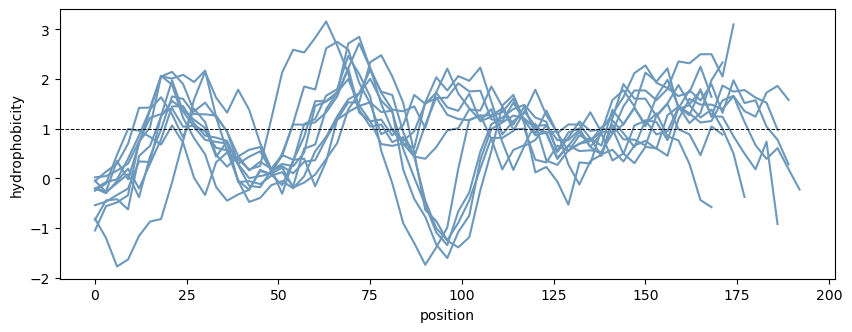

In [10]:
HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

window_size = 20
step_size = 3

cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

fig, ax = plt.subplots(figsize=(10, 3.5))
for row in genes_df.itertuples():
    window_starts = list(range(0, len(row.seq), step_size))[:-1]
    windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]
    hydrophobicity = [get_hydrophobicity(window) for window in windows]
    ax.plot(window_starts, hydrophobicity, label=gene_id, color=palette[gene_id])

ax.set_ylabel('hydrophobicity')
ax.set_xlabel('position')
ax.axhline(1, ls='--', color='black', lw=0.7)
plt.show()